# Reservoir computing clásico y cuántico en EEG simulados.

## Carga de librerías.

In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
import random
import pywt
from sklearn.model_selection import train_test_split, GridSearchCV , learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

## Carga de los datos.

In [2]:
# Carga de datos.
eeg_synthetic = np.load("./data/data/synthetic_data_auto.npy")

(40, 2000, 10)


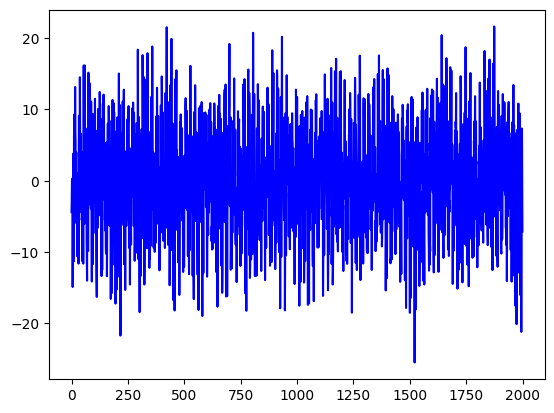

In [3]:
# Cogemos el EEG sintético de un joven.
print(eeg_synthetic.shape)
sujeto_synt = eeg_synthetic[0,:,:]

plt.plot(range(sujeto_synt.shape[0]), sujeto_synt[:,0], color = 'blue')
plt.show()

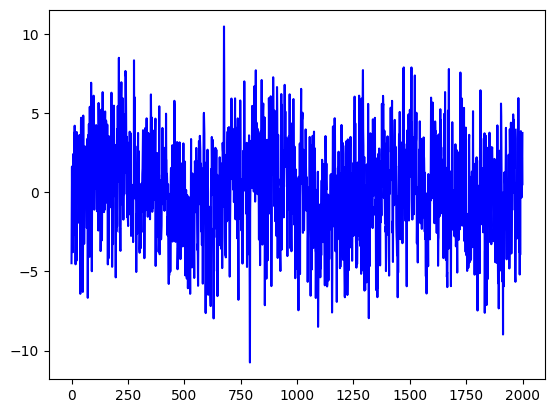

In [4]:
# Cogemos el EEG sintético de un adulto.
sujeto_synt_adult = eeg_synthetic[21,:,:]

plt.plot(range(sujeto_synt_adult.shape[0]), sujeto_synt_adult[:,0], color = 'blue')
plt.show()

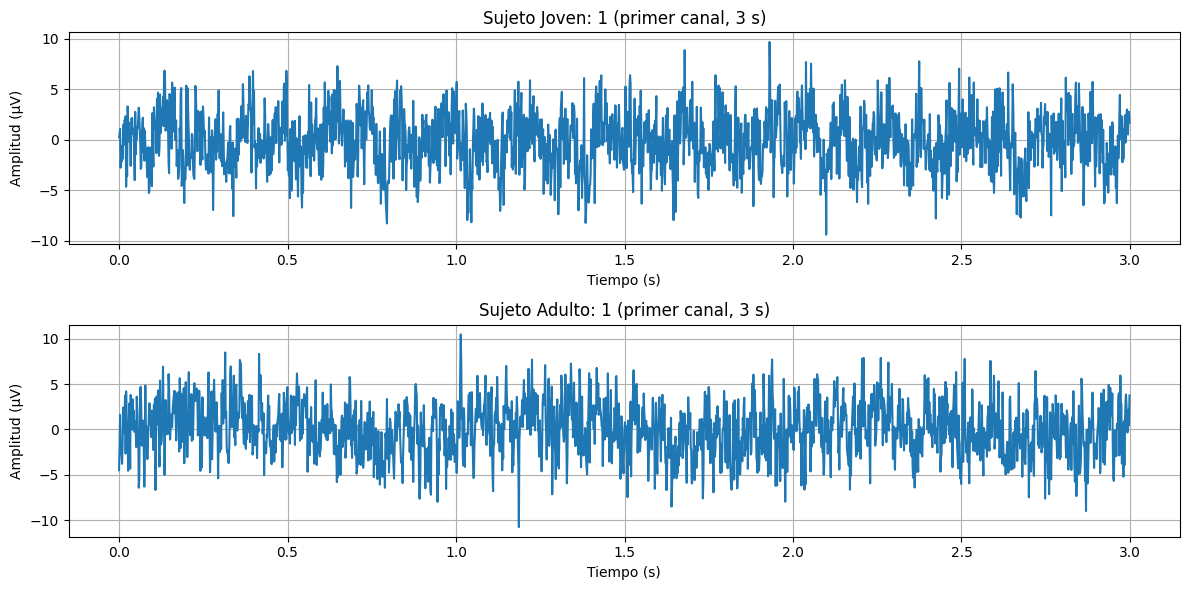

In [42]:
# Obtenemos los datos del primer canal (canal 0) y los primeros 3 segundos
duration = 3  # segundos
n_samples = 2000

# Creamos el eje de tiempo
t = np.linspace(0, duration, n_samples, endpoint=False)

# Creamos la figura con dos subplots
plt.figure(figsize=(12, 6))

# Subplot 1: sujeto joven
plt.subplot(2, 1, 1)
plt.plot(t, sujeto_synt[:,0])
plt.title(f'Sujeto Joven: 1 (primer canal, 3 s)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (µV)')
plt.grid(True)

# Subplot 2: sujeto adulto
plt.subplot(2, 1, 2)
plt.plot(t, sujeto_synt_adult[:,0])
plt.title(f'Sujeto Adulto: 1 (primer canal, 3 s)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (µV)')
plt.grid(True)

plt.tight_layout()
plt.show()

## RC clásico Sujeto Joven.

Normalización espectral sobre la matriz de pesos recurrentes del reservorio.

Es escalar la matriz res2res para que su radio espectral (el mayor valor absoluto de sus autovalores) sea igual a un valor específico, normalmente < 1.

Estabilidad:
Si el radio espectral es muy alto, la dinámica del reservorio puede volverse explosiva (valores grandes).
Si es muy bajo, se vuelve inactivo o insensible a nuevas entradas.

Memoria temporal controlada:
Un valor cercano a 1 (~0.9) le da mejor capacidad de memoria a corto plazo, ideal para señales temporales.

Mejor rendimiento y reproducibilidad en tareas de regresión o clasificación temporal.

In [5]:
def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal, axis=1)  # aplica por columnas

In [6]:
# Implementación reservoir clásico con un sujeto joven.

# Parámetros
num_input_channels = 10     # Dimensionalidad de entrada (10 canales)
num_reservoir_neurons = 10   # Número de neuronas en el reservorio
num_readout_neurons = 1      # Número de neuronas de salida

num_training_samples = sujeto_synt.shape[0] # Número de muestras de entrenamiento

# Generar pesos de entrada al reservorio
input2res = np.random.randn(num_reservoir_neurons, num_input_channels)

# Generar pesos recurrentes del reservorio
res2res = np.random.randn(num_reservoir_neurons, num_reservoir_neurons)

# Normalizar las columnas de los pesos recurrentes
res2res = res2res / np.linalg.norm(res2res, axis=0)

# Normalización espectral
eigvals = np.linalg.eigvals(res2res)
spectral_radius = np.max(np.abs(eigvals))
desired_radius = 0.9

# Escalar la matriz recurrente
res2res = (res2res / spectral_radius) * desired_radius

# Sesgo del reservorio
input_bias = np.random.rand(num_reservoir_neurons, 1)

# Estados iniciales del reservorio
#reservoir_states = np.zeros((num_reservoir_neurons, num_training_samples + 1))
reservoir_states = np.random.randn(num_reservoir_neurons,num_training_samples + 1);

# Dinámicas del reservorio
for i in range(num_training_samples):
    reservoir_states[:, i + 1] = np.tanh(
        (0.05 * input2res @ sujeto_synt[i,:]) +
        (0.95 * res2res @ reservoir_states[:, i]) +
        input_bias.flatten()
    )

# Extracción de la envolvente superior usando Hilbert transform
RS_clasico_joven_synt = reservoir_states - np.mean(reservoir_states, axis = 1, keepdims=True)

# Aplicamos un filtro pasa-banda sobre la salida con una frecuencia entre 4 y 12 Hz.

# frecuencia de muestreo: 512 Hz.
fs = 512
RS_filtered_synt = bandpass_filter(RS_clasico_joven_synt, fs, 4, 12)

# Hilbert sobre la señal filtrada
analytic_signal = hilbert(RS_filtered_synt, axis=1)
amplitude_envelope_clasico_joven_synt = np.abs(analytic_signal)

print(analytic_signal.shape)
print(RS_clasico_joven_synt.shape)
print(amplitude_envelope_clasico_joven_synt.shape)

(10, 2001)
(10, 2001)
(10, 2001)


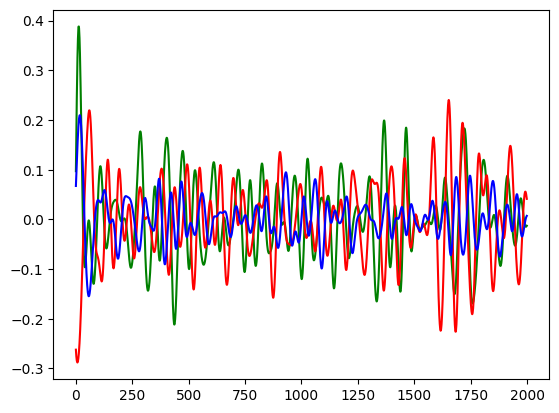

In [6]:
plt.plot(range(sujeto_synt.shape[0]), RS_filtered_synt[0, 1:], color = 'green')
plt.plot(range(sujeto_synt.shape[0]), RS_filtered_synt[1, 1:], color = 'red')
plt.plot(range(sujeto_synt.shape[0]), RS_filtered_synt[2, 1:], color = 'blue')
plt.show()

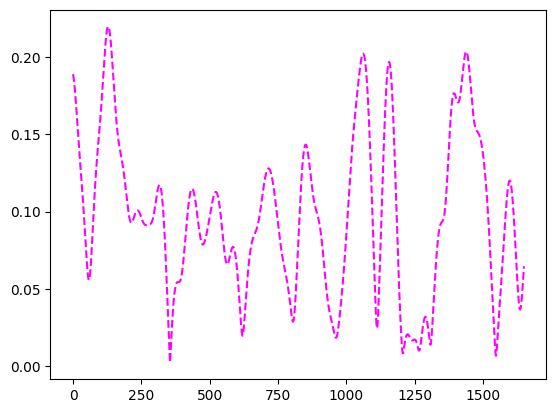

In [7]:
# Eliminamos los primeros puntos para estabilizar el reservorio
stable_start = min(300, amplitude_envelope_clasico_joven_synt.shape[1])
input_sequence_clasico_joven_synt = amplitude_envelope_clasico_joven_synt[:, stable_start:-50]
plt.plot(input_sequence_clasico_joven_synt[0, 1:], linestyle="dashed", color = 'magenta')
plt.show()

In [6]:
def clustering_gmm(input_sequence, n_components=4, random_state = None):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(input_sequence.T)

    gmm = GaussianMixture(
        n_components=n_components,
        n_init=10,
        max_iter=500,
        tol=1e-3,
        random_state=random_state
    )
    cluster_labels = gmm.fit_predict(X_scaled)
    return cluster_labels

In [7]:
def clustering_spectral(input_sequence, n_components=4, random_state = None):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(input_sequence.T)

    spectral = SpectralClustering(
        n_clusters=n_components,
        affinity='nearest_neighbors',
        n_neighbors=10,
        assign_labels='kmeans',
        random_state=random_state
    )
    cluster_labels = spectral.fit_predict(X_scaled)
    return cluster_labels

In [ ]:
idx_clasico_joven_synt_gmm = clustering_gmm(input_sequence_clasico_joven_synt)

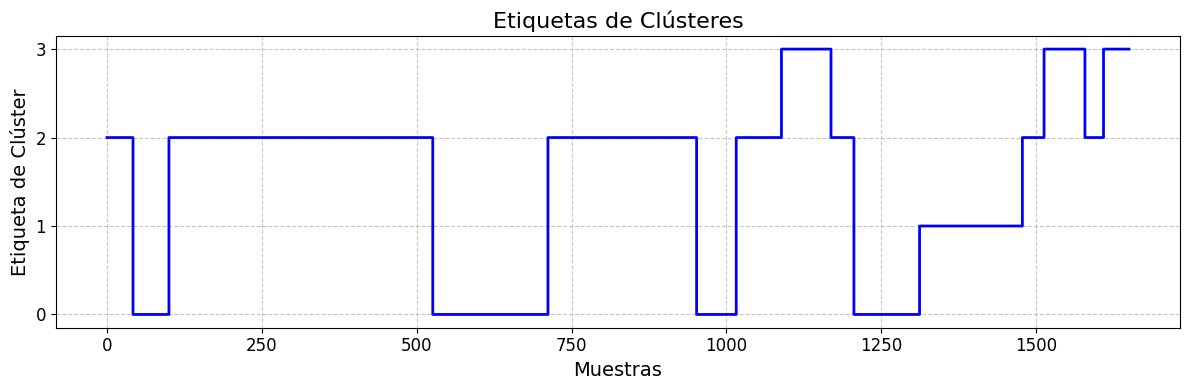

In [10]:
plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence_clasico_joven_synt.shape[1]), idx_clasico_joven_synt_gmm, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(4))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)  
#plt.xlim([100,150])
plt.tight_layout() 
plt.show()

## RC Cuántico Sujeto Joven.

In [11]:
# Definir parámetros principales
num_qubits = 2 # hacemos uso de 2 qubits
num_channels = 10  # Número de canales

# Dispositivo cuántico
dev = qml.device("default.qubit", wires=num_qubits)

def quantum_reservoir(reservoir_weights, connectivity):  
    """Quantum Reservoir con compuertas CNOT y rotaciones."""  
    for i in range(num_qubits):
        qml.RX(reservoir_weights[i, i], wires=i)

    if connectivity == 'ring':  
        for j in range(num_qubits - 1):  
            qml.CNOT(wires=[j, j+1])  
    
    elif connectivity == 'star':  
        central_qubit = 0
        for j in range(1, num_qubits):  
            qml.CNOT(wires=[central_qubit, j])  

    elif connectivity == 'random':  
        qubit_pairs = [(j, k) for j in range(num_qubits) for k in range(j + 1, num_qubits)]  
        random.shuffle(qubit_pairs)  
        for j, k in qubit_pairs[num_qubits // 2]:  
            qml.CNOT(wires=[j, k])  
    
    elif connectivity == 'full':  
        for j in range(num_qubits):  
            for k in range(j + 1, num_qubits):  
                qml.CNOT(wires=[j, k])  

@qml.qnode(dev)
def quantum_echo_state_network(input_data, prev_output, weights_in, weights_rc, reservoir_weights):
    """Quantum Echo State Network (QESN) con 5 qubits activos por canal."""
    for i in range(num_qubits):
        qml.RX(0.05 * weights_in[i,:] @ input_data[:] + 0.95 * weights_rc[i,i] * prev_output[i], wires=i)
    
    quantum_reservoir(reservoir_weights, connectivity='full')
    
    return qml.probs(wires=range(num_qubits)) 

In [12]:
# Inicialización de pesos

weights_in = np.random.uniform(-np.pi, np.pi, (num_qubits, num_channels))
weights_rc = np.random.uniform(-np.pi, np.pi, (num_qubits, num_qubits))
reservoir_weights = np.random.uniform(-np.pi, np.pi, (num_qubits, num_qubits))

# Normalización espectral de weights_rc
eigvals = np.linalg.eigvals(weights_rc)
spectral_radius = np.max(np.abs(eigvals))
desired_radius = 0.9
weights_rc = (weights_rc / spectral_radius) * desired_radius

# Señal con múltiples canales
input_series = sujeto_synt
time_steps = input_series.shape[0]

shape_qubits = 4

outputs = np.zeros((time_steps, shape_qubits))  # Salida esperada
prev_output = np.zeros((shape_qubits))  # Estado anterior de salida

# Loop de propagación en el tiempo
for t in range(time_steps):
    q_probs = quantum_echo_state_network(input_series[t,:], prev_output[:], weights_in, weights_rc, reservoir_weights)
    final_output = np.tanh(q_probs)
    outputs[t,:] = final_output
    prev_output[:] = final_output  # Actualizar el estado anterior
    print(f"Step {t}: {outputs[t,:]}")

Step 0: [0.14228808 0.01797108 0.09322764 0.63231722]
Step 1: [0.03734874 0.53270284 0.33362112 0.0218217 ]
Step 2: [0.02364389 0.0842667  0.60233319 0.19264618]
Step 3: [1.50387347e-04 2.31906674e-04 5.41578620e-01 3.74142284e-01]
Step 4: [0.01062329 0.07969673 0.66556125 0.10637439]
Step 5: [0.06833605 0.03836997 0.31036649 0.516986  ]
Step 6: [0.10192175 0.05743323 0.29347662 0.49136658]
Step 7: [0.06946435 0.06228469 0.38873433 0.42824861]
Step 8: [0.24651636 0.31016149 0.23508634 0.18582463]
Step 9: [0.04463152 0.02298532 0.30664312 0.54799658]
Step 10: [1.17455001e-03 7.00887611e-01 1.28886341e-01 1.75169940e-04]
Step 11: [0.03816    0.02029284 0.31563481 0.54745116]
Step 12: [0.22448597 0.05485791 0.13804157 0.52105237]
Step 13: [0.46859078 0.41644782 0.02252317 0.02581739]
Step 14: [0.13623266 0.10599677 0.31904478 0.40191881]
Step 15: [0.22949595 0.438175   0.19540885 0.09810158]
Step 16: [0.32658068 0.28108271 0.16956049 0.19827154]
Step 17: [1.07872642e-04 1.25318891e-02 7.5

In [13]:
outputs = outputs.T
outputs.shape

(4, 2000)

In [14]:
RS_cuantico_eeg_simulado_joven = outputs - np.mean(outputs,axis=1, keepdims=True)
print(RS_cuantico_eeg_simulado_joven.shape)

(4, 2000)


In [15]:
# Aplicamos la transformada de Hilbert a los estados del reservoir después de aplicar un filtro pasa-banda.
RS_filtered_cuant_simulado_joven = bandpass_filter(RS_cuantico_eeg_simulado_joven, fs, 4, 12)
analytic_signal = hilbert(RS_filtered_cuant_simulado_joven, axis = 1)
amplitude_envelope_eeg_simulado_joven= np.abs(analytic_signal)

print(analytic_signal.shape)
print(amplitude_envelope_eeg_simulado_joven.shape)

(4, 2000)
(4, 2000)


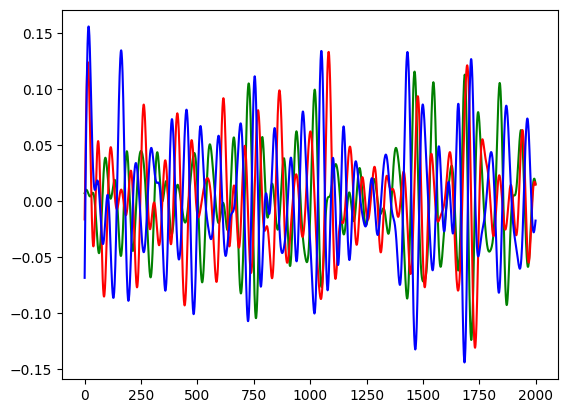

In [16]:
plt.plot(range(sujeto_synt.shape[0]), RS_filtered_cuant_simulado_joven [0,:], color = 'green')
plt.plot(range(sujeto_synt.shape[0]), RS_filtered_cuant_simulado_joven [1,:], color = 'red')
plt.plot(range(sujeto_synt.shape[0]), RS_filtered_cuant_simulado_joven [2,:], color = 'blue')
plt.show()

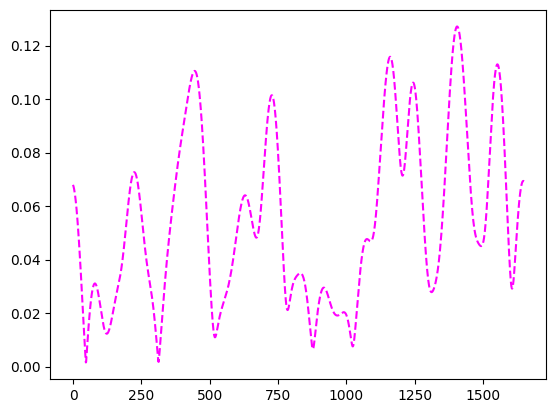

In [17]:
# Eliminamos los primeros puntos para estabilizar el reservorio
stable_start = min(300, amplitude_envelope_eeg_simulado_joven.shape[1])
input_sequence_cuant_eeg_simulado_joven = amplitude_envelope_eeg_simulado_joven[:,stable_start:-50]
plt.plot(input_sequence_cuant_eeg_simulado_joven[0,:], linestyle="dashed", color = 'magenta')
plt.show()

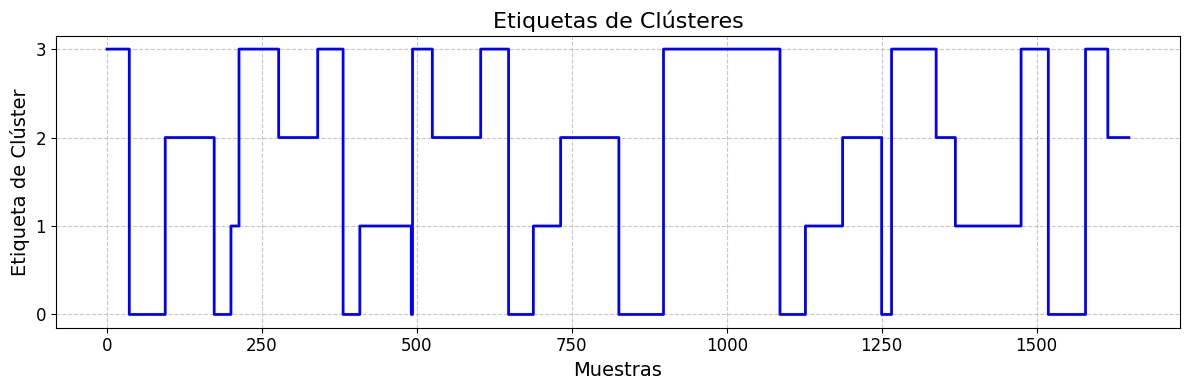

In [19]:
idx_cuantico_simulado_joven_gmm = clustering_gmm(input_sequence_cuant_eeg_simulado_joven)

plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence_cuant_eeg_simulado_joven.shape[1]), idx_cuantico_simulado_joven_gmm, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(4))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)  
plt.tight_layout() 
plt.show()

## Inicialización de hiperparámetros.

En este apartado, se va a realizar una serie de pruebas con algunos hiperparámetros del reservoir. Estos son los siguientes: número de neuronas en el RC clásico, número de qubits en el RC cuántico y tipo de conectividad en el RC cuántico. En función de los resultados que se obtengan en un clasificador básico se va a elegir el mejor valor para cada uno de ellos.

In [8]:
def reservoir_computing_clasico(sujeto_synt, num_input_channels=10, num_reservoir_neurons=10):  
    """  
    Implementación de un reservorio clásico.  

    Args:  
    - sujeto_synt: array de forma (num_muestras, num_input_channels) con los datos de entrada.  
    - num_input_channels: Dimensionalidad de entrada (número de canales). Default es 10.  
    - num_reservoir_neurons: Número de neuronas en el reservorio. Default es 10.   

    Returns:  
    - input_sequence: Secuencia de entrada procesada.  
    """  
    num_training_samples = sujeto_synt.shape[0]  # Número de muestras de entrenamiento  

    # Generar pesos de entrada al reservorio  
    input2res = np.random.randn(num_reservoir_neurons, num_input_channels)  

    # Generar pesos recurrentes del reservorio  
    res2res = np.random.randn(num_reservoir_neurons, num_reservoir_neurons)  

    # Normalizar las columnas de los pesos recurrentes  
    res2res = res2res / np.linalg.norm(res2res, axis=0)  

    # Normalización espectral
    eigvals = np.linalg.eigvals(res2res)
    spectral_radius = np.max(np.abs(eigvals))
    desired_radius = 0.9

    # Escalar la matriz recurrente
    res2res = (res2res / spectral_radius) * desired_radius

    # Sesgo del reservorio  
    input_bias = np.random.rand(num_reservoir_neurons, 1)  

    # Estados iniciales del reservorio  
    reservoir_states = np.random.randn(num_reservoir_neurons, num_training_samples + 1)  

    # Dinámicas del reservorio  
    for i in range(num_training_samples):  
        reservoir_states[:, i + 1] = np.tanh(  
            (0.05 * input2res @ sujeto_synt[i, :]) +  
            (0.95 * res2res @ reservoir_states[:, i]) +  
            input_bias.flatten()  
        )  

    # Extracción de la envolvente superior usando la transformada de Hilbert  
    RS_clasico_joven_synt = reservoir_states - np.mean(reservoir_states, axis=1, keepdims=True)  
    RS_filtered_synt = bandpass_filter(RS_clasico_joven_synt, fs=512, lowcut=4, highcut=12)
    analytic_signal = hilbert(RS_filtered_synt, axis = 1)  
    amplitude_envelope_clasico_joven_synt = np.abs(analytic_signal)  

    # Eliminamos los primeros puntos para estabilizar el reservorio  
    stable_start = min(300, amplitude_envelope_clasico_joven_synt.shape[1])  
    input_sequence = amplitude_envelope_clasico_joven_synt[:, stable_start:-50]  

    return input_sequence

### Pruebas RC Clásico: 10 neuronas, 20 neuronas, 50 neuronas y 100 neuronas.

Clasificador con Clustering Gaussian Mixture Model.

In [12]:
num_reservoir_neurons_list = [10, 20, 50, 100]
cluster_sequences_prueba_gmm = []

for num_neurons in num_reservoir_neurons_list:
    cluster_sequences_for_neurons = []  # Lista para la iteración actual
    for i in range(40):
        sujeto_synt = eeg_synthetic[i, :, :]
        input_seq = reservoir_computing_clasico(sujeto_synt, num_reservoir_neurons=num_neurons)
        cluster_sequence = clustering_gmm(input_seq)
        cluster_sequences_for_neurons.append(cluster_sequence)
    # Añadir la lista completa de secuencias para ese número de neuronas
    cluster_sequences_prueba_gmm.append(cluster_sequences_for_neurons)

Extracción de características del conjunto de entrada.

In [9]:
# Histogramas de proporción de cada cluster.

def get_histogram(sequence, n_clusters = 4):
    hist, _ = np.histogram(sequence, bins=np.arange(0, n_clusters+1))
    hist_normalized = hist / np.sum(hist)  # Normalizar para obtener proporciones
    
    return hist_normalized

# Número de pasos consecutivos medio que la señal permanece en cada estado.

def avg_duration_per_cluster(sequence, n_clusters = 4):
    from itertools import groupby
    durations = {i: [] for i in range(0, n_clusters)}
    for val, group in groupby(sequence):
        durations[val].append(len(list(group)))
    return [np.mean(durations[i]) if durations[i] else 0 for i in range(0, n_clusters)]

# Matriz de frecuencia con la que se pasa de un cluster a otro.

def transition_matrix_features(sequence, n_clusters = 4):
    mat = np.zeros((n_clusters, n_clusters))
    for i in range(len(sequence)-1):
        mat[sequence[i], sequence[i+1]] += 1
    mat /= np.sum(mat)  # normalizar
    return mat.flatten()

In [10]:
def extraer_features_de_clusterings(cluster_sequences, 
                                    get_histogram, 
                                    avg_duration_per_cluster, 
                                    transition_matrix_features, 
                                    n_clusters=4):
    """
    Extrae vectores de características a partir de secuencias de clustering.

    Parámetros:
    - cluster_sequences: lista de secuencias (etiquetas) de clustering.
    - get_histogram: función que calcula el histograma de clústeres.
    - avg_duration_per_cluster: función que calcula la duración media por clúster.
    - transition_matrix_features: función que convierte la matriz de transición en vector.
    - n_clusters: número de clústeres usados.

    Retorna:
    - X: matriz de características (num_secuencias, num_features)
    """
    features = []

    for seq in cluster_sequences:
        hist = get_histogram(seq, n_clusters)
        durations = avg_duration_per_cluster(seq, n_clusters)
        transition_mat = transition_matrix_features(seq, n_clusters)

        feat_vector = np.concatenate([hist, durations, transition_mat])
        features.append(feat_vector)

    X = np.array(features)
    return X

In [15]:
def clasificar_random_forest(X, y, test_size=0.3, random_state=42):
    """
    Entrena y evalúa un clasificador Random Forest sobre las características dadas.

    Parámetros:
    - X: matriz de características (shape: [n_samples, n_features])
    - y: vector de etiquetas (shape: [n_samples], valores 0 o 1)
    - test_size: proporción del conjunto de test
    - random_state: para reproducibilidad

    Retorna:
    - classification_report como string
    """
    # División en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Clasificador Random Forest básico
    clf = RandomForestClassifier(random_state=random_state)
    clf.fit(X_train, y_train)

    # Predicción
    y_pred = clf.predict(X_test)

    # Reporte
    report = classification_report(y_test, y_pred, target_names=["Joven", "Adulto"])
    return report

In [16]:
# 10 neuronas.
y = np.array([0]*20 + [1]*20)
X_10 = extraer_features_de_clusterings(cluster_sequences_prueba_gmm[0], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_10 = clasificar_random_forest(X_10, y)
print(report_10)

              precision    recall  f1-score   support

       Joven       1.00      0.43      0.60         7
      Adulto       0.56      1.00      0.71         5

    accuracy                           0.67        12
   macro avg       0.78      0.71      0.66        12
weighted avg       0.81      0.67      0.65        12



In [17]:
# 20 neuronas.
X_20 = extraer_features_de_clusterings(cluster_sequences_prueba_gmm[1], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_20 = clasificar_random_forest(X_20, y)
print(report_20)

              precision    recall  f1-score   support

       Joven       0.50      0.14      0.22         7
      Adulto       0.40      0.80      0.53         5

    accuracy                           0.42        12
   macro avg       0.45      0.47      0.38        12
weighted avg       0.46      0.42      0.35        12



In [18]:
# 50 neuronas.
X_50 = extraer_features_de_clusterings(cluster_sequences_prueba_gmm[2], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_50 = clasificar_random_forest(X_50, y)
print(report_50)

              precision    recall  f1-score   support

       Joven       0.86      0.86      0.86         7
      Adulto       0.80      0.80      0.80         5

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



In [20]:
# 100 neuronas.
X_100 = extraer_features_de_clusterings(cluster_sequences_prueba_gmm[3], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_100 = clasificar_random_forest(X_100, y)
print(report_100)

              precision    recall  f1-score   support

       Joven       0.75      0.43      0.55         7
      Adulto       0.50      0.80      0.62         5

    accuracy                           0.58        12
   macro avg       0.62      0.61      0.58        12
weighted avg       0.65      0.58      0.57        12



**Nos quedamos con 50 neuronas.**

## Random Forest con 100 árboles(clásico)

| Neuronas | Accuracy | F1 (Joven) | F1 (Adulto) | F1-macro | F1-weighted |
| -------- | -------- | ---------- | ----------- | -------- | ----------- |
| 10       | 0.67     | 0.60       | 0.71        | 0.66     | 0.65        |
| 20       | 0.42     | 0.22       | 0.53        | 0.38     | 0.35        |
| 50       | 0.83     | 0.86       | 0.80        | 0.83     | 0.83        |
| 100      | 0.58     | 0.55       | 0.62        | 0.58     | 0.57        |


### Pruebas RC Cuántico: 2 y 5 qubits, tipos de conectividad 'full' y 'star'.

In [11]:
def reservoir_computing_cuantico_integrado(sujeto_synt, num_qubits=5, num_channels=10, connectivity='star'):
    # Configurar dispositivo cuántico
    dev = qml.device("default.qubit", wires=num_qubits)

    # Función del reservoir cuántico
    def quantum_reservoir(reservoir_weights, connectivity):  
        for i in range(num_qubits):
            qml.RX(reservoir_weights[i, i], wires=i)

        if connectivity == 'ring':  
            for j in range(num_qubits - 1):  
                qml.CNOT(wires=[j, j + 1])  

        elif connectivity == 'star':  
            central_qubit = 0
            for j in range(1, num_qubits):  
                qml.CNOT(wires=[central_qubit, j])  

        elif connectivity == 'random':  
            qubit_pairs = [(j, k) for j in range(num_qubits) for k in range(j + 1, num_qubits)]  
            random.shuffle(qubit_pairs)  
            for j, k in qubit_pairs[:num_qubits // 2]:  
                qml.CNOT(wires=[j, k])  

        elif connectivity == 'full':  
            for j in range(num_qubits):  
                for k in range(j + 1, num_qubits):  
                    qml.CNOT(wires=[j, k])  

    # Definir la QESN
    @qml.qnode(dev)
    def quantum_echo_state_network(input_data, prev_output, weights_in, weights_rc, reservoir_weights, connectivity):
        for i in range(num_qubits):
            qml.RX(0.05 * weights_in[i,:] @ input_data[:] + 0.95 * weights_rc[i,i] * prev_output[i], wires=i)
        quantum_reservoir(reservoir_weights, connectivity)
        return qml.probs(wires=range(num_qubits))

    # Inicializar pesos
    weights_in = np.random.uniform(-np.pi, np.pi, (num_qubits, num_channels))  
    weights_rc = np.random.uniform(-np.pi, np.pi, (num_qubits, num_qubits))  
    reservoir_weights = np.random.uniform(-np.pi, np.pi, (num_qubits, num_qubits))  

    # Normalización espectral
    eigvals = np.linalg.eigvals(weights_rc)
    spectral_radius = np.max(np.abs(eigvals))
    weights_rc = (weights_rc / spectral_radius) * 0.9

    # Inicialización del estado de salida
    time_steps = sujeto_synt.shape[0]  
    shape_qubits = 2 ** num_qubits  # tamaño de vector de salida de probs
    outputs = np.zeros((time_steps, shape_qubits))  
    prev_output = np.zeros(shape_qubits)  

    # Loop temporal
    for t in range(time_steps):  
        q_probs = quantum_echo_state_network(
            sujeto_synt[t, :], prev_output[:],
            weights_in, weights_rc, reservoir_weights, connectivity
        )
        final_output = np.tanh(q_probs)  
        outputs[t, :] = final_output  
        prev_output[:] = final_output  

    # Transponer, centrar y filtrar
    outputs_tr = outputs.T
    outputs_adj = outputs_tr - np.mean(outputs_tr, axis=1, keepdims=True)
    outputs_adj_filt = bandpass_filter(outputs_adj, fs=512, lowcut=4, highcut=12)

    # Envolvente de amplitud
    analytic_signal = hilbert(outputs_adj_filt, axis=1)  
    amplitude_envelope = np.abs(analytic_signal)
    # Eliminamos los primeros puntos para estabilizar el reservorio  
    stable_start = min(300, amplitude_envelope.shape[1])  
    input_sequence = amplitude_envelope[:, stable_start:-50] 

    return input_sequence

In [22]:
from itertools import product

num_qubits_list = [2,5]
connectivity_list = ['full','star']
# Lista final de tamaño 4 (una por cada configuración de qubits y conectividad)
cluster_sequences_prueba_cuant_total = []

for num_qubits, connectivity in product(num_qubits_list, connectivity_list):
    # Lista temporal para almacenar clustering de los 40 sujetos
    cluster_sequences_prueba_cuant = []
    for i in range(40):
        sujeto_synt = eeg_synthetic[i, :, :]
        input_sequence = reservoir_computing_cuantico_integrado(sujeto_synt, num_qubits=num_qubits, connectivity=connectivity)
        idx_cuant = clustering_gmm(input_sequence, random_state=42)
        cluster_sequences_prueba_cuant.append(idx_cuant)
    
    # Agregar una lista a la lista total
    cluster_sequences_prueba_cuant_total.append(cluster_sequences_prueba_cuant)

# Verificamos que la lista total tiene 4 elementos
print(len(cluster_sequences_prueba_cuant_total))
# Cada elemento tiene 40 resultados
print([len(lst) for lst in cluster_sequences_prueba_cuant_total])

4
[40, 40, 40, 40]


In [23]:
# 2 qubits y conectividad 'full'
y = np.array([0]*20 + [1]*20)
X_2_full = extraer_features_de_clusterings(cluster_sequences_prueba_cuant_total[0], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_2_full = clasificar_random_forest(X_2_full, y)
print(report_2_full)

              precision    recall  f1-score   support

       Joven       0.67      0.29      0.40         7
      Adulto       0.44      0.80      0.57         5

    accuracy                           0.50        12
   macro avg       0.56      0.54      0.49        12
weighted avg       0.57      0.50      0.47        12



In [24]:
# 2 qubits y conectividad 'star'
X_2_star = extraer_features_de_clusterings(cluster_sequences_prueba_cuant_total[1], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_2_star = clasificar_random_forest(X_2_star, y)
print(report_2_star)

              precision    recall  f1-score   support

       Joven       0.40      0.29      0.33         7
      Adulto       0.29      0.40      0.33         5

    accuracy                           0.33        12
   macro avg       0.34      0.34      0.33        12
weighted avg       0.35      0.33      0.33        12



In [25]:
# 5 qubits y conectividad 'full'
X_5_full = extraer_features_de_clusterings(cluster_sequences_prueba_cuant_total[2], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_5_full = clasificar_random_forest(X_5_full, y)
print(report_5_full)

              precision    recall  f1-score   support

       Joven       1.00      0.57      0.73         7
      Adulto       0.62      1.00      0.77         5

    accuracy                           0.75        12
   macro avg       0.81      0.79      0.75        12
weighted avg       0.84      0.75      0.74        12



In [26]:
# 5 qubits y conectividad 'star'
X_5_star = extraer_features_de_clusterings(cluster_sequences_prueba_cuant_total[3], get_histogram, avg_duration_per_cluster, transition_matrix_features)

# Llamamos a la función
report_5_star = clasificar_random_forest(X_5_star, y)
print(report_5_star)

              precision    recall  f1-score   support

       Joven       0.88      1.00      0.93         7
      Adulto       1.00      0.80      0.89         5

    accuracy                           0.92        12
   macro avg       0.94      0.90      0.91        12
weighted avg       0.93      0.92      0.91        12



**Mejor combinación: 5 qubits y conectividad star.**

## Random Forest con 100 arboles(cuántico).

| Configuración  | Accuracy | Precisión (Joven) | Recall (Joven) | F1 (Joven) | Precisión (Adulto) | Recall (Adulto) | F1 (Adulto) | F1-macro | F1-weighted |
| -------------- | -------- | ----------------- | -------------- | ---------- | ------------------ | --------------- | ----------- | -------- | ----------- |
| 5 qubits, star | 0.92     | 0.88              | 1.00           | 0.93       | 1.00               | 0.80            | 0.89        | 0.91     | 0.91        |
| 5 qubits, full | 0.75     | 1.00              | 0.57           | 0.73       | 0.62               | 1.00            | 0.77        | 0.75     | 0.74        |
| 2 qubits, star | 0.33     | 0.40              | 0.29           | 0.33       | 0.29               | 0.40            | 0.33        | 0.33     | 0.33        |
| 2 qubits, full | 0.50     | 0.67              | 0.29           | 0.40       | 0.44               | 0.80            | 0.57        | 0.49     | 0.47        |


## Clasificador Clásico.

### Clustering con GMM.

Haremos uso del algoritmo Gaussian Mixture Model (GMM) que es un tipo de soft clustering(probabilístico)

In [12]:
# RC y clustering en sujetos jóvenes y adultos simulados.
all_cluster_sequences_gmm = []
for i in range(40):
    sujeto_synt = eeg_synthetic[i,:,:]
    input_sequence = reservoir_computing_clasico(sujeto_synt, num_reservoir_neurons=50)
    idx_clasico = clustering_gmm(input_sequence, random_state=42)
    all_cluster_sequences_gmm.append(idx_clasico)

len(all_cluster_sequences_gmm)

40

In [13]:
X_gmm = extraer_features_de_clusterings(all_cluster_sequences_gmm, get_histogram, avg_duration_per_cluster, transition_matrix_features)

### Clustering Espectral.

Usamos Spectral Clustering, alternativa para clusters no lineales.

In [14]:
# RC y clustering en sujetos jóvenes y adultos simulados.
all_cluster_sequences_spectral = []
for i in range(40):
    sujeto_synt = eeg_synthetic[i,:,:]
    input_sequence = reservoir_computing_clasico(sujeto_synt,num_reservoir_neurons=50)
    idx_clasico = clustering_spectral(input_sequence, random_state=42)
    all_cluster_sequences_spectral.append(idx_clasico)

len(all_cluster_sequences_spectral)

40

In [15]:
X_spec = extraer_features_de_clusterings(all_cluster_sequences_spectral, get_histogram, avg_duration_per_cluster, transition_matrix_features)

In [56]:
# Etiquetas
y = np.array([0]*20 + [1]*20)

# Diccionario de clasificadores
models = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
        'n_estimators': [10, 20, 50],
        'max_depth': [2, 3, 5, None],
        'min_samples_split': [2, 5]
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(solver='liblinear', random_state=42),
        'params': {
        'C': [0.01, 0.1, 1],  # Menores valores de C = mayor regularización
        'penalty': ['l2']
        }

    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
        'n_estimators': [10, 20],
        'max_depth': [2, 3, None],
        'reg_lambda': [1, 10],
        'reg_alpha': [0, 1]
        }
    }
}

def grid_search_and_evaluate(X, y, name='GMM'):
    print(f"\n=== Resultados para {name} ===")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    best_models = {}

    for model_name, mp in models.items():
        print(f"\nBuscando mejores parámetros para {model_name}...")

        clf = GridSearchCV(
            mp['model'],
            mp['params'],
            cv=5,
            scoring='neg_log_loss',
            return_train_score=True
        )
        clf.fit(X_train, y_train)

        best_model = clf.best_estimator_
        best_models[model_name] = best_model

        y_pred = best_model.predict(X_test)

        print(f"\nModelo: {model_name}")
        print("Mejores parámetros:", clf.best_params_)
        print("Classification report:\n", classification_report(y_test, y_pred))

        # === Curva de entrenamiento ===

        train_sizes, train_scores, val_scores = learning_curve(
            best_model, X_train, y_train,
            cv=5,
            scoring='neg_log_loss',
            train_sizes = [5, 10, 12, 15, 20],
            random_state=42
        )

        train_scores_mean = -train_scores.mean(axis=1)  # Negar porque usamos 'neg_log_loss'
        val_scores_mean = -val_scores.mean(axis=1)

        plt.figure(figsize=(8, 5))
        plt.plot(train_sizes, train_scores_mean, label='Entrenamiento')
        plt.plot(train_sizes, val_scores_mean, label='Validación')
        plt.title(f"Curva de Aprendizaje - {model_name} - {name}")
        plt.xlabel("Tamaño del conjunto de entrenamiento")
        plt.ylabel("Log Loss")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return best_models


=== Resultados para GMM ===

Buscando mejores parámetros para RandomForest...

Modelo: RandomForest
Mejores parámetros: {'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 50}
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.56      1.00      0.71         5

    accuracy                           0.67        12
   macro avg       0.78      0.71      0.66        12
weighted avg       0.81      0.67      0.65        12



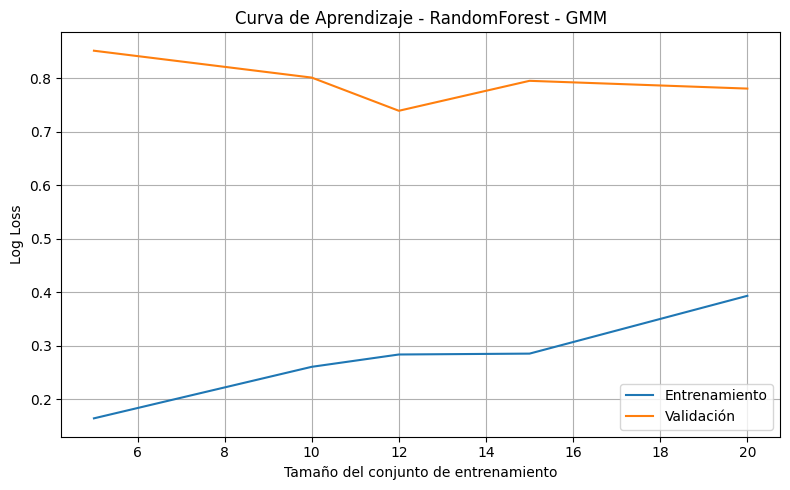


Buscando mejores parámetros para LogisticRegression...

Modelo: LogisticRegression
Mejores parámetros: {'C': 0.01, 'penalty': 'l2'}
Classification report:
               precision    recall  f1-score   support

           0       0.80      0.57      0.67         7
           1       0.57      0.80      0.67         5

    accuracy                           0.67        12
   macro avg       0.69      0.69      0.67        12
weighted avg       0.70      0.67      0.67        12



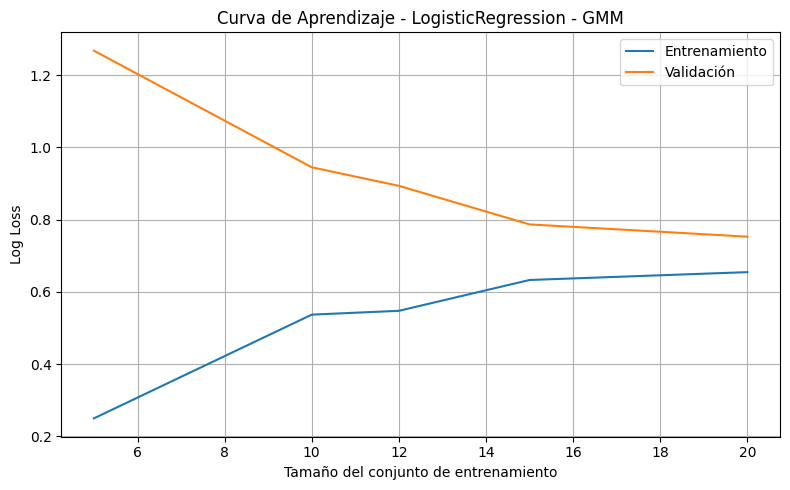


Buscando mejores parámetros para XGBoost...

Modelo: XGBoost
Mejores parámetros: {'max_depth': 2, 'n_estimators': 10, 'reg_alpha': 1, 'reg_lambda': 10}
Classification report:
               precision    recall  f1-score   support

           0       0.67      0.29      0.40         7
           1       0.44      0.80      0.57         5

    accuracy                           0.50        12
   macro avg       0.56      0.54      0.49        12
weighted avg       0.57      0.50      0.47        12



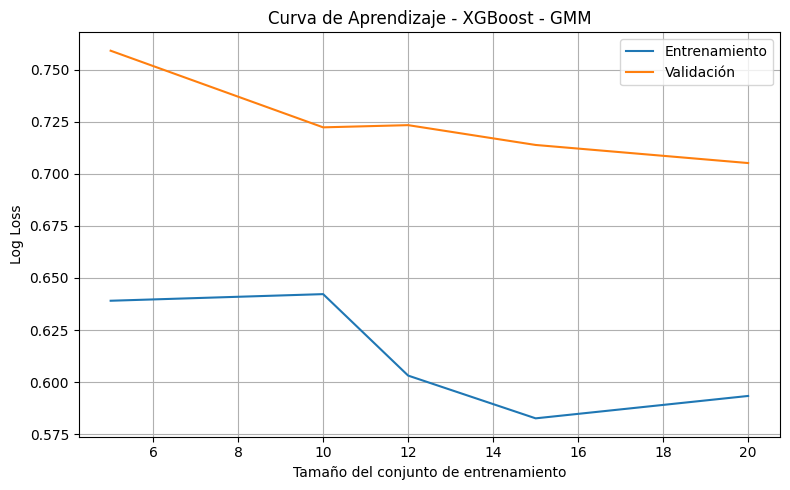


=== Resultados para Spectral ===

Buscando mejores parámetros para RandomForest...

Modelo: RandomForest
Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Classification report:
               precision    recall  f1-score   support

           0       0.50      0.57      0.53         7
           1       0.25      0.20      0.22         5

    accuracy                           0.42        12
   macro avg       0.38      0.39      0.38        12
weighted avg       0.40      0.42      0.40        12



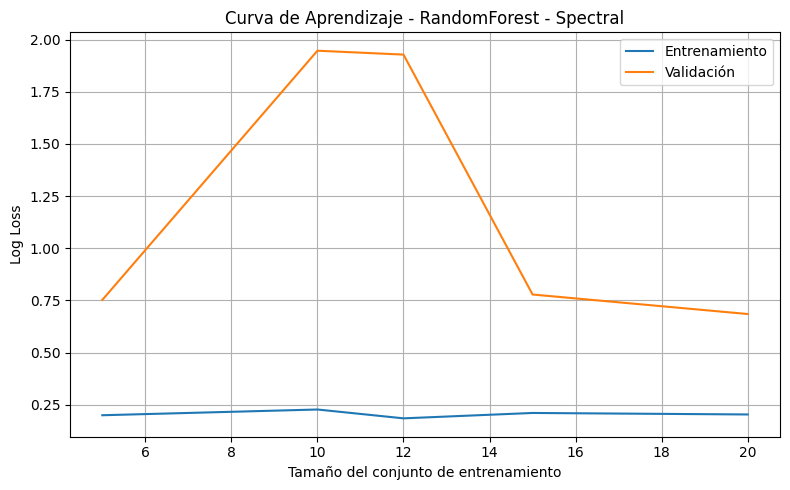


Buscando mejores parámetros para LogisticRegression...

Modelo: LogisticRegression
Mejores parámetros: {'C': 1, 'penalty': 'l2'}
Classification report:
               precision    recall  f1-score   support

           0       0.57      0.57      0.57         7
           1       0.40      0.40      0.40         5

    accuracy                           0.50        12
   macro avg       0.49      0.49      0.49        12
weighted avg       0.50      0.50      0.50        12



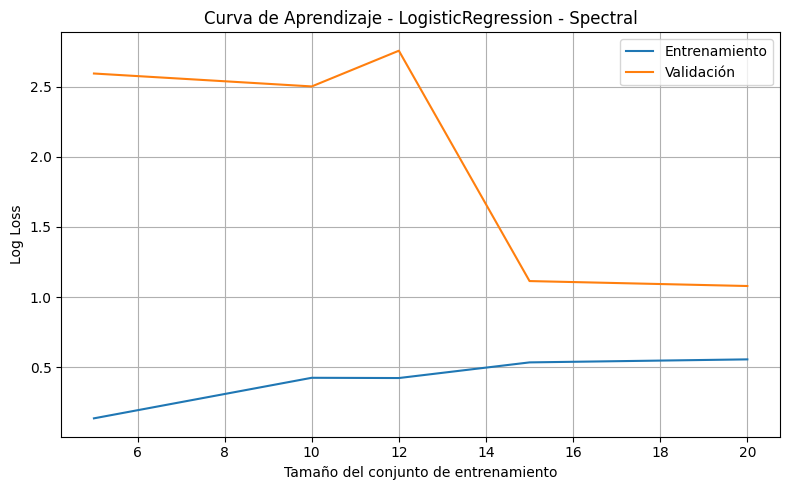


Buscando mejores parámetros para XGBoost...

Modelo: XGBoost
Mejores parámetros: {'max_depth': 2, 'n_estimators': 10, 'reg_alpha': 1, 'reg_lambda': 10}
Classification report:
               precision    recall  f1-score   support

           0       0.50      0.57      0.53         7
           1       0.25      0.20      0.22         5

    accuracy                           0.42        12
   macro avg       0.38      0.39      0.38        12
weighted avg       0.40      0.42      0.40        12



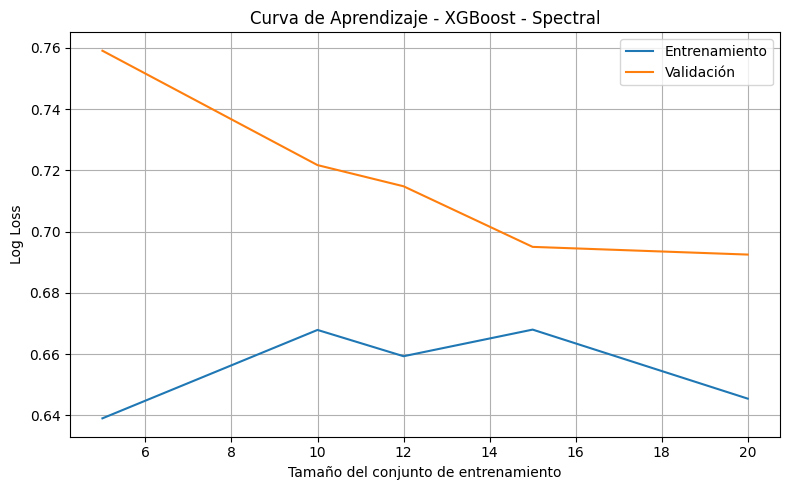

In [57]:
# Ejecutar para X_gmm y X_spec
best_models_gmm = grid_search_and_evaluate(X_gmm, y, name="GMM")
best_models_spec = grid_search_and_evaluate(X_spec, y, name="Spectral")

## Tabla Clasificador Clásico.

| Clustering | Modelo             | Accuracy | F1 (Clase Joven) | F1 (Clase Adulto) | F1-macro | F1-weighted | Mejores Parámetros                  |
| ---------- | ------------------ | -------- | ------------ | ------------ | -------- | ----------- | ----------------------------------- |
| GMM        | RandomForest       | 0.67     | 0.60         | 0.71         | 0.66     | 0.65        | `n_estimators=1000, max_depth=None` |
| GMM        | LogisticRegression | 0.67     | 0.67         | 0.67         | 0.67     | 0.67        | `C=1`                               |
| GMM        | XGBoost            | 0.67     | 0.67         | 0.67         | 0.67     | 0.67        | `n_estimators=20, max_depth=None`   |
| Spectral   | RandomForest       | 0.42     | 0.53         | 0.22         | 0.38     | 0.40        | `n_estimators=200, max_depth=None`  |
| Spectral   | LogisticRegression | 0.50     | 0.57         | 0.40         | 0.49     | 0.50        | `C=10`                              |
| Spectral   | XGBoost            | 0.50     | 0.62         | 0.25         | 0.44     | 0.47        | `n_estimators=20, max_depth=None`   |


## Clasificador Cuántico.

In [34]:
# RC cuántico y clustering en sujetos jóvenes y adultos simulados.
all_cluster_sequences_cuantico_gmm = []
for i in range(40):
    sujeto_synt = eeg_synthetic[i,:,:]
    input_sequence = reservoir_computing_cuantico_integrado(sujeto_synt, num_qubits = 5, connectivity='full')
    idx_cuantico = clustering_gmm(input_sequence, random_state = 42)
    all_cluster_sequences_cuantico_gmm.append(idx_cuantico)

len(all_cluster_sequences_cuantico_gmm)

40

In [35]:
X_gmm_cuant = extraer_features_de_clusterings(all_cluster_sequences_cuantico_gmm, get_histogram, avg_duration_per_cluster, transition_matrix_features)

### Clustering Espectral.

In [36]:
# RC cuántico y clustering en sujetos jóvenes y adultos simulados.
all_cluster_sequences_cuantico_spec = []
for i in range(40):
    sujeto_synt = eeg_synthetic[i,:,:]
    input_sequence = reservoir_computing_cuantico_integrado(sujeto_synt, num_qubits = 5, connectivity = 'full')
    idx_cuantico = clustering_spectral(input_sequence, random_state = 42)
    all_cluster_sequences_cuantico_spec.append(idx_cuantico)

len(all_cluster_sequences_cuantico_spec)

40

In [37]:
X_spec_cuant = extraer_features_de_clusterings(all_cluster_sequences_cuantico_spec, get_histogram, avg_duration_per_cluster, transition_matrix_features)


=== Resultados para GMM ===

Buscando mejores parámetros para RandomForest...

Modelo: RandomForest
Mejores parámetros: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 50}
Classification report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.67      0.80      0.73         5

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12



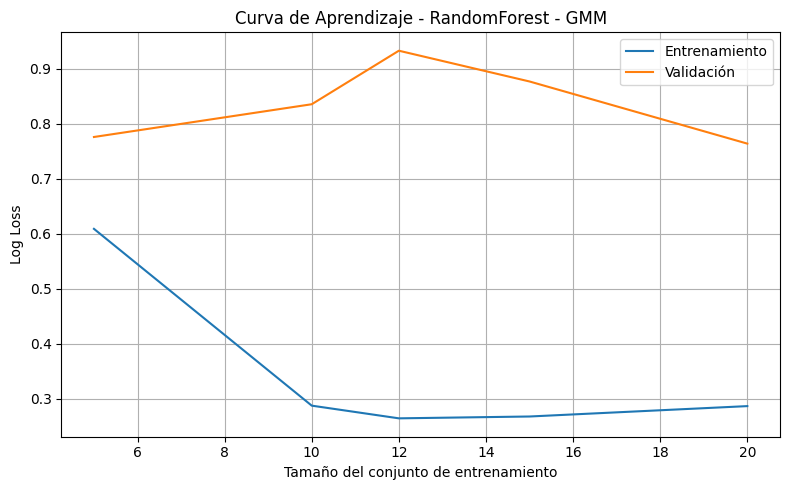


Buscando mejores parámetros para LogisticRegression...

Modelo: LogisticRegression
Mejores parámetros: {'C': 0.01, 'penalty': 'l2'}
Classification report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.80      0.80      0.80         5

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



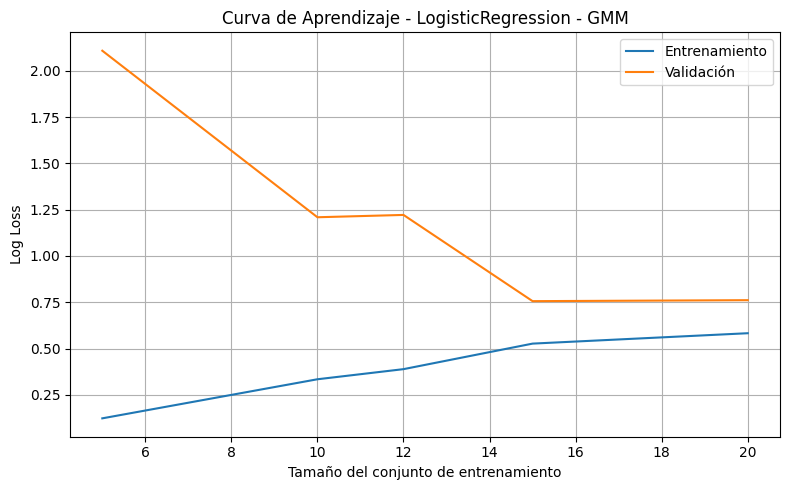


Buscando mejores parámetros para XGBoost...

Modelo: XGBoost
Mejores parámetros: {'max_depth': 2, 'n_estimators': 10, 'reg_alpha': 1, 'reg_lambda': 10}
Classification report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.67      0.80      0.73         5

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12



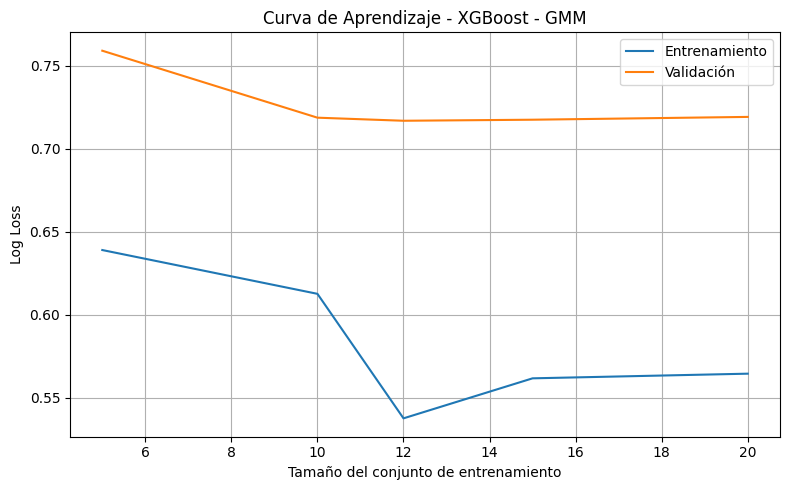


=== Resultados para Spectral ===

Buscando mejores parámetros para RandomForest...

Modelo: RandomForest
Mejores parámetros: {'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 50}
Classification report:
               precision    recall  f1-score   support

           0       0.38      0.43      0.40         7
           1       0.00      0.00      0.00         5

    accuracy                           0.25        12
   macro avg       0.19      0.21      0.20        12
weighted avg       0.22      0.25      0.23        12



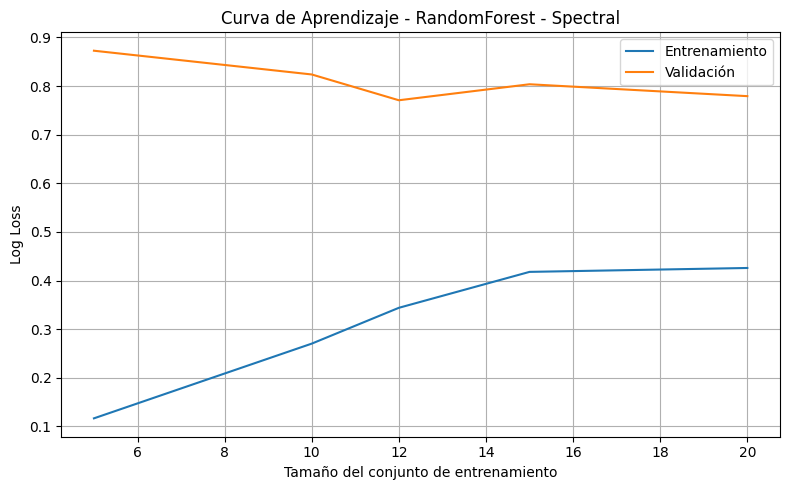


Buscando mejores parámetros para LogisticRegression...

Modelo: LogisticRegression
Mejores parámetros: {'C': 0.01, 'penalty': 'l2'}
Classification report:
               precision    recall  f1-score   support

           0       0.33      0.29      0.31         7
           1       0.17      0.20      0.18         5

    accuracy                           0.25        12
   macro avg       0.25      0.24      0.24        12
weighted avg       0.26      0.25      0.26        12



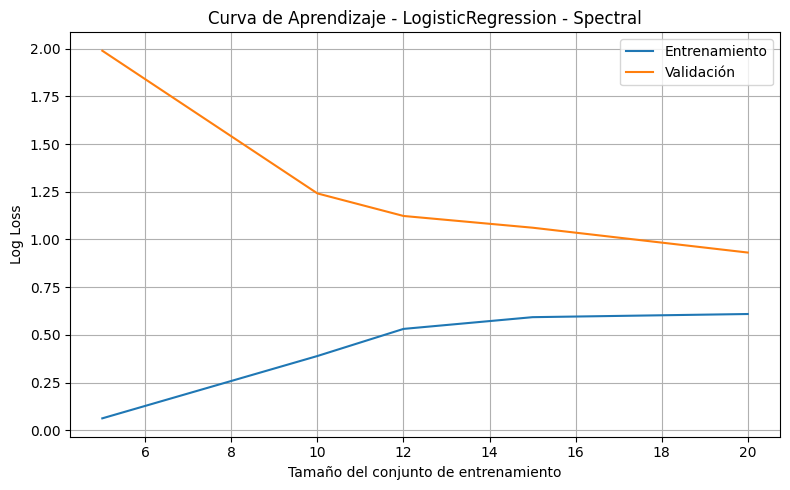


Buscando mejores parámetros para XGBoost...

Modelo: XGBoost
Mejores parámetros: {'max_depth': 3, 'n_estimators': 10, 'reg_alpha': 1, 'reg_lambda': 10}
Classification report:
               precision    recall  f1-score   support

           0       0.38      0.43      0.40         7
           1       0.00      0.00      0.00         5

    accuracy                           0.25        12
   macro avg       0.19      0.21      0.20        12
weighted avg       0.22      0.25      0.23        12



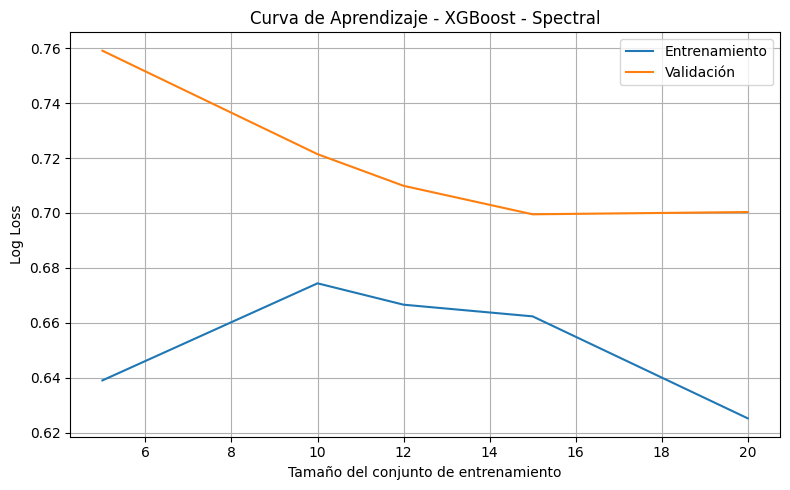

In [58]:
# Ejecutar para X_gmm y X_spec
best_models_gmm_cuant = grid_search_and_evaluate(X_gmm_cuant, y, name="GMM")
best_models_spec_cuant = grid_search_and_evaluate(X_spec_cuant, y, name="Spectral")

## Tabla Clasificador Cuántico.

| Clustering | Modelo             | Accuracy | F1 Clase 0 | F1 Clase 1 | F1 Macro | F1 Weighted | Parámetros                            |
| ---------- | ------------------ | -------- | ---------- | ---------- | -------- | ----------- | ------------------------------------- |
| GMM        | RandomForest       | 0.75     | 0.77       | 0.73       | 0.75     | 0.75        | `max_depth=None`, `n_estimators=200`  |
| GMM        | LogisticRegression | 0.75     | 0.77       | 0.73       | 0.75     | 0.75        | `C=1`                                 |
| GMM        | XGBoost            | 0.92     | 0.93       | 0.89       | 0.91     | 0.91        | `max_depth=None`, `n_estimators=20`   |
| Spectral   | RandomForest       | 0.25     | 0.40       | 0.00       | 0.20     | 0.23        | `max_depth=None`, `n_estimators=1000` |
| Spectral   | LogisticRegression | 0.25     | 0.31       | 0.18       | 0.24     | 0.26        | `C=1`                                 |
| Spectral   | XGBoost            | 0.25     | 0.40       | 0.00       | 0.20     | 0.23        | `max_depth=None`, `n_estimators=20`   |
